## Linear Regression 

1. Load and understand the dataset
2. Data preprocessing
3. EDA
4. Create separate **X** and **Y** DataFrames
5. Encode categorical features
6. Split into `train_x`, `test_x`, `train_y`, `test_y`
7. Feature scaling
8. Train Linear Regression
9. Calculate MSE, RMSE, MAE and R² Score


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("e-com_cleaned_dataset.csv")
df.head()

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,2639.48,328.29,2285.92,1613.24,612.14,28.36
2,ORD100995,C1410,2025-07-13,35.0,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


In [3]:
df.shape

(2852, 32)

In [4]:
df.dtypes

Order_ID                    object
Customer_ID                 object
Order_Date                  object
Customer_Age               float64
Customer_Segment            object
City                        object
Region                      object
Category                    object
Product_Name                object
Sales_Channel               object
Payment_Method              object
Device                      object
Quantity                     int64
Unit_Price                 float64
Discount_Pct               float64
Shipping_Days              float64
Customer_Rating            float64
Delivery_Rating            float64
Return_Status               object
Order_Status                object
Marketing_Source            object
Customer_Loyalty_Points    float64
Website_Session_Minutes    float64
Items_Viewed                 int64
Previous_Orders              int64
Customer_Satisfaction      float64
Gross_Amount               float64
Discount_Amount            float64
Net_Sales           

In [5]:
df.isnull().sum()

Order_ID                   0
Customer_ID                0
Order_Date                 0
Customer_Age               0
Customer_Segment           0
City                       0
Region                     0
Category                   0
Product_Name               0
Sales_Channel              0
Payment_Method             0
Device                     0
Quantity                   0
Unit_Price                 0
Discount_Pct               0
Shipping_Days              0
Customer_Rating            0
Delivery_Rating            0
Return_Status              0
Order_Status               0
Marketing_Source           0
Customer_Loyalty_Points    0
Website_Session_Minutes    0
Items_Viewed               0
Previous_Orders            0
Customer_Satisfaction      0
Gross_Amount               0
Discount_Amount            0
Net_Sales                  0
Estimated_Cost             0
Profit                     0
Profit_Margin_Pct          0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

### Data Preprocessing

`Order_Date` is a date column. Instead of giving the raw date string to the model, we extract:

- `Order_Year`
- `Order_Month`
- `Order_Day`


In [7]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day

In [8]:
df = df.drop(columns=["Order_Year"])

###  EDA – Exploratory Data Analysis

In [9]:
df.describe()

,Order_Date,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,...,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct,Order_Month,Order_Day
count,2852,2852.000000,2852.000000,2852.000000,2852.00000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,...,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000
mean,2025-07-02 02:53:11.023843072,35.404278,3.254909,1568.004386,15.16892,4.541024,3.747475,3.676017,869.173913,14.677139,...,5.004909,3.665288,5138.416476,753.366189,4285.255754,3064.366655,1213.317921,28.352048,6.532258,15.640252
min,2025-01-01 00:00:00,0.000000,1.000000,12.750000,0.00000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1394.000000,12.040000,1.000000,1.000000
25%,2025-03-31 00:00:00,28.000000,2.000000,489.052500,8.54000,3.000000,3.300000,3.100000,377.000000,8.000000,...,3.000000,3.100000,1253.302500,119.872500,1097.265000,785.170000,293.767500,20.845000,3.000000,8.000000
50%,2025-07-01 00:00:00,35.000000,3.000000,922.380000,14.90500,4.000000,3.800000,3.700000,828.000000,12.700000,...,5.000000,3.700000,2639.480000,328.290000,2285.920000,1613.240000,612.140000,28.360000,7.000000,16.000000
75%,2025-10-02 00:00:00,42.000000,4.000000,1797.110000,21.08500,6.000000,4.300000,4.300000,1268.500000,19.300000,...,6.000000,4.300000,5578.300000,749.090000,4472.040000,3205.825000,1225.102500,35.602500,10.000000,23.000000
max,2025-12-31 00:00:00,102.000000,40.000000,61182.500000,75.00000,35.000000,5.000000,5.000000,2970.000000,96.100000,...,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000,12.000000,31.000000
std,NaN,11.137747,1.868876,2369.922175,9.29384,2.265459,0.734697,0.841038,618.464339,9.469406,...,2.289158,0.821690,9061.894474,1654.471979,7458.582159,5250.740997,2484.419099,9.018859,3.462787,8.820930


In [10]:
df = df.drop(columns=["Order_ID", "Customer_ID"])

In [11]:
df.select_dtypes(include=np.number).corr()["Net_Sales"].sort_values(ascending=False)

Net_Sales                  1.000000
Estimated_Cost             0.983586
Gross_Amount               0.962388
Profit                     0.924182
Unit_Price                 0.820237
Discount_Amount            0.779221
Quantity                   0.322330
Items_Viewed               0.020611
Order_Month                0.014342
Delivery_Rating            0.013572
Order_Day                  0.009675
Profit_Margin_Pct          0.005947
Customer_Satisfaction      0.002945
Website_Session_Minutes    0.002773
Customer_Age              -0.001501
Customer_Loyalty_Points   -0.006623
Customer_Rating           -0.008825
Previous_Orders           -0.021622
Shipping_Days             -0.021988
Discount_Pct              -0.070684
Name: Net_Sales, dtype: float64



- A value close to `+1` indicates a strong positive relationship.
- A value close to `-1` indicates a strong negative relationship.
- A value close to `0` indicates a weak linear relationship.


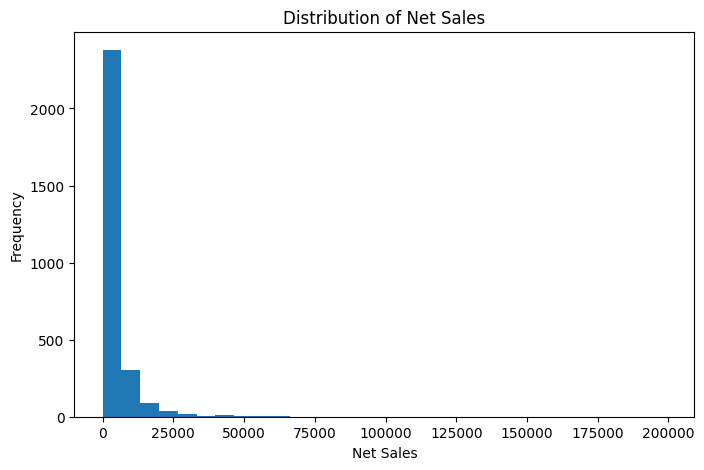

In [12]:
df["Net_Sales"].plot(kind="hist", bins=30, figsize=(8, 5))
plt.xlabel("Net Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Net Sales")
plt.show()

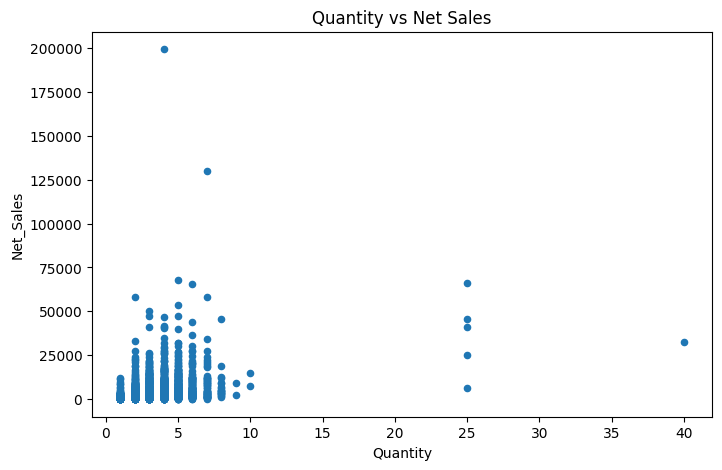

In [13]:
df.plot.scatter(x="Quantity", y="Net_Sales", figsize=(8, 5))
plt.title("Quantity vs Net Sales")
plt.show()

### 3. Create X and Y DataFrames

#### Y – Target

`Net_Sales` is the value we want the model to predict.

#### X – Features

We use customer, order, product, pricing, rating, marketing, and browsing-related information.

We deliberately exclude:

- IDs
- raw date
- product name
- order/return status
- `Gross_Amount`
- `Discount_Amount`
- `Estimated_Cost`
- `Profit`
- `Profit_Margin_Pct`

The calculated financial columns are excluded to reduce target leakage because they are directly derived from transaction amounts/costs.

In [14]:
feature_columns = [
    "Customer_Age",
    "Customer_Segment",
    "Region",
    "Category",
    "Sales_Channel",
    "Payment_Method",
    "Device",
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Shipping_Days",
    "Customer_Rating",
    "Delivery_Rating",
    "Marketing_Source",
    "Customer_Loyalty_Points",
    "Website_Session_Minutes",
    "Items_Viewed",
    "Previous_Orders",
    "Customer_Satisfaction",
    "Order_Month",
    "Order_Day"
]

X = df[feature_columns].copy()
Y = df[["Net_Sales"]].copy()

X.head()
Y.head()

,Net_Sales
0,723.34
1,2285.92
2,633.37
3,26531.41
4,7999.40


In [15]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

X[numerical_columns] = X[numerical_columns].fillna(X[numerical_columns].median())
X[categorical_columns] = X[categorical_columns].fillna(X[categorical_columns].mode().iloc[0])

### Encoding


In [16]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(X[categorical_columns])

X_categorical = pd.DataFrame(
    X_categorical,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

X_numerical = X[numerical_columns]

X_encoded = pd.concat([X_numerical, X_categorical], axis=1)

X_encoded.head()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,...,Payment_Method_Net Banking,Payment_Method_Upi,Payment_Method_Wallet,Device_Laptop,Device_Mobile,Device_Tablet,Marketing_Source_Google Ads,Marketing_Source_Organic,Marketing_Source_Referral,Marketing_Source_Social Media
0,44.0,2,361.67,0.00,6.0,2.9,5.0,1062.0,16.4,10,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,51.0,2,922.38,28.01,5.0,2.5,3.6,1252.0,23.2,9,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,35.0,1,739.05,14.30,7.0,3.9,3.7,0.0,9.1,10,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,38.0,4,7001.11,5.26,4.0,3.5,3.5,1388.0,22.7,4,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,39.0,2,4920.89,18.72,4.0,5.0,4.6,1132.0,6.6,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [17]:
X_encoded.shape

(2852, 43)

### Train-Test Split


In [18]:
train_x, test_x, train_y, test_y = train_test_split(
    X_encoded,
    Y,
    test_size=0.20,
    random_state=42
)

In [19]:
scaler = StandardScaler()

train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

##  Linear Regression


In [20]:
model = LinearRegression()
model.fit(train_x, train_y.values.ravel())

LinearRegression()

In [21]:
predictions = model.predict(test_x)

## Model Evaluation

In [23]:
mse = mean_squared_error(test_y, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_y, predictions)
r2 = r2_score(test_y, predictions)

print("\nModel Performance:")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")


Model Performance:
Mean Absolute Error: 1579.81
Mean Squared Error: 23915566.65
Root Mean Squared Error: 4890.35
R² Score: 0.8123
